# Decision Tree Classification/Regression

In [1324]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [1325]:
dataset = pd.read_csv('../data/pokemon_alopez247.csv')

In [1326]:
dataset.head()
dataset.columns
print(dataset['Type_1'].unique())
print(dataset['Type_2'].unique())
print(dataset.isna().sum().sort_values(ascending=False))

<StringArray>
[   'Grass',     'Fire',    'Water',      'Bug',   'Normal',   'Poison',
 'Electric',   'Ground',    'Fairy', 'Fighting',  'Psychic',     'Rock',
    'Ghost',      'Ice',   'Dragon',     'Dark',    'Steel',   'Flying']
Length: 18, dtype: str
<StringArray>
[  'Poison',        nan,   'Flying',   'Ground',    'Fairy',    'Grass',
 'Fighting',  'Psychic',    'Steel',      'Ice',     'Rock',    'Water',
 'Electric',     'Fire',   'Dragon',     'Dark',    'Ghost',      'Bug',
   'Normal']
Length: 19, dtype: str
Egg_Group_2         530
Type_2              371
Pr_Male              77
Type_1                0
Total                 0
Name                  0
Number                0
Attack                0
HP                    0
Defense               0
Sp_Atk                0
Generation            0
isLegendary           0
Sp_Def                0
Speed                 0
hasGender             0
Color                 0
Egg_Group_1           0
hasMegaEvolution      0
Height_m           

In [1327]:
# Imputing the missing values of Type_2 with 'None'
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='most_frequent', fill_value='None')
dataset[['Type_2', 'Egg_Group_2', 'Pr_Male']] = imputer.fit_transform(dataset[['Type_2', 'Egg_Group_2', 'Pr_Male']])
dataset.isna().sum().sort_values(ascending=False)

# Simple Python logic to bin the long tail
series = dataset['Color'].value_counts()
top_colors = series[series >50].index # Keep colors that appear more than 80 times

dataset['Color'] = dataset['Color'].apply(lambda x: x if x in top_colors else 'Other')

In [1328]:
dataset['Color'].value_counts()

Color
Blue      134
Brown     110
Green      79
Red        75
Other      73
Grey       69
Purple     65
Yellow     64
White      52
Name: count, dtype: int64

From back elemiation we have seen that the least significant features are:

'Sp_Atk', 'isLegendary'

In [ ]:
from sklearn.preprocessing import LabelEncoder


X = dataset['Color']
X = pd.get_dummies(X, columns=['Color']).astype(int)
y = dataset['Type_1']

<StringArray>
[   'Grass',     'Fire',    'Water',      'Bug',   'Normal',   'Poison',
 'Electric',   'Ground',    'Fairy', 'Fighting',  'Psychic',     'Rock',
    'Ghost',      'Ice',   'Dragon',     'Dark',    'Steel',   'Flying']
Length: 18, dtype: str
['Bug' 'Dark' 'Dragon' 'Electric' 'Fairy' 'Fighting' 'Fire' 'Flying'
 'Ghost' 'Grass' 'Ground' 'Ice' 'Normal' 'Poison' 'Psychic' 'Rock' 'Steel'
 'Water']


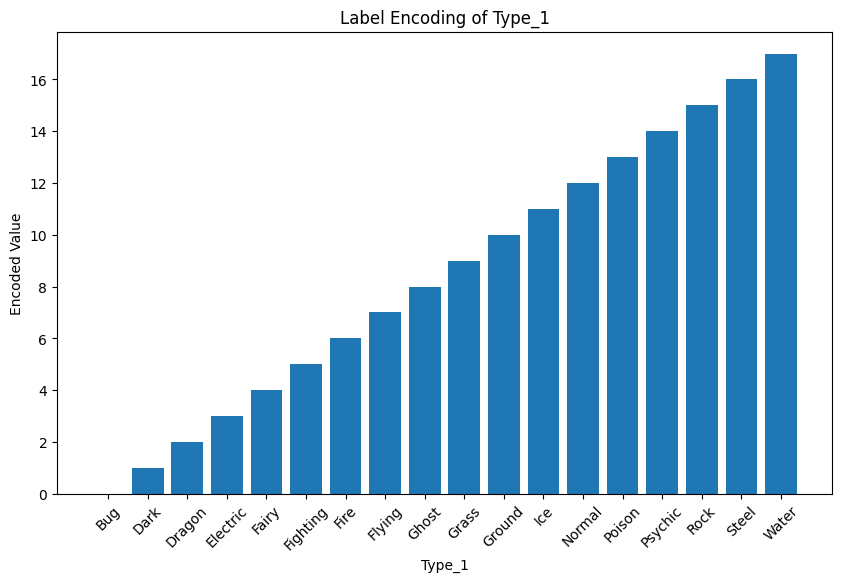

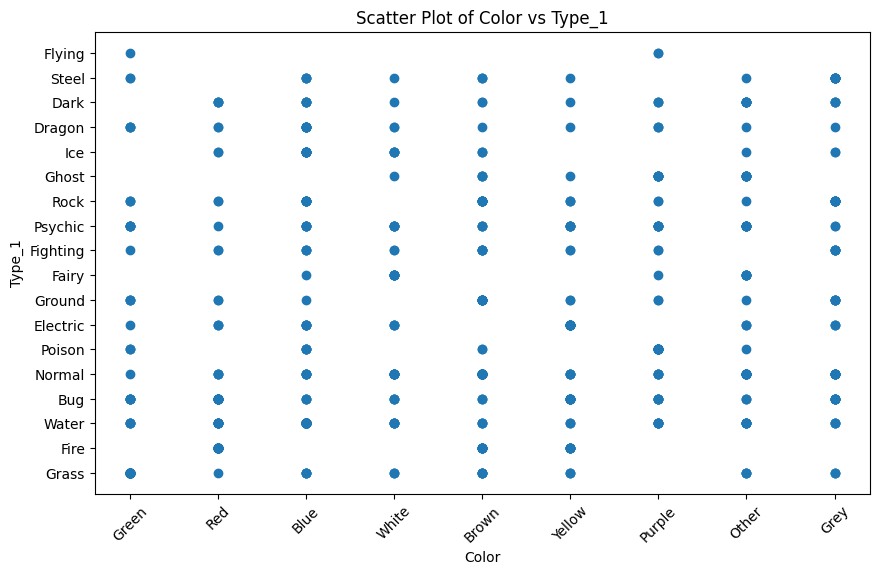

In [1337]:
print(y.unique())
le_y = LabelEncoder()
le_y.fit(y)
le_y.transform(y)
print(le_y.classes_)

plt.figure(figsize=(10, 6))
plt.bar(le_y.classes_, le_y.transform(le_y.classes_))
plt.xlabel('Type_1')
plt.ylabel('Encoded Value')
plt.title('Label Encoding of Type_1')
plt.xticks(rotation=45)
plt.show()

## Color and Type_1 are the only features we are using for this model. We will use Decision Tree Classifier to predict the Type_1 based on Color.
plt.figure(figsize=(10, 6))
plt.scatter(dataset['Color'], dataset['Type_1'])
plt.xlabel('Color')
plt.ylabel('Type_1')
plt.title('Scatter Plot of Color vs Type_1')
plt.xticks(rotation=45)
plt.show()

In [1331]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [1332]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion='entropy', max_depth=2, random_state=0)

In [1333]:
classifier.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [1334]:
y_hat = classifier.predict(x_test)

In [1335]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_hat))
print(le_y.inverse_transform(y_test))
print(le_y.inverse_transform(y_hat))


0.2482758620689655


TypeError: '<' not supported between instances of 'str' and 'int'

## Above is without scaling the data. 

Decision Tree does not require feature scaling as it is based on the concept of splitting the data into subsets based on the feature values. It is not affected by the scale of the features, as it uses a tree structure to make decisions based on the feature values rather than calculating distances between data points. Therefore, it can handle both numerical and categorical features without the need for scaling.

In [ ]:
import statsmodels.api as sm
X = sm.add_constant(X)  # Adding a constant term for the intercept
model = sm.OLS(y, X).fit()  # Fit the model with all features
p_values = model.pvalues  # Get p-values for each feature
least_significant_feature = p_values.idxmax()  # Identify the least significant feature
print("Least significant feature:", least_significant_feature)

Least significant feature: White
